# طبقه بندی گل ها

## دانلود دیتاست

In [1]:
import tensorflow as tf
import keras
from keras import layers
import pathlib
url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = pathlib.Path(tf.keras.utils.get_file('flower_photos', origin=url, untar=True))
if (data_dir / "flower_photos").is_dir():
    data_dir = data_dir / "flower_photos"
print(list(data_dir.iterdir()))


228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
[PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses'), PosixPath('/root/.keras/datasets/flower_photos/flower_photos/LICENSE.txt'), PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion'), PosixPath('/root/.keras/datasets/flower_photos/flower_photos/sunflowers'), PosixPath('/root/.keras/datasets/flower_photos/flower_photos/daisy'), PosixPath('/root/.keras/datasets/flower_photos/flower_photos/tulips')]


## آماده کردن عکس ها

In [2]:
IMG = 160
BATCH = 32
train_ds_raw = keras.utils.image_dataset_from_directory(data_dir, validation_split=0.2, subset="training", seed=123, image_size=(IMG, IMG), batch_size=BATCH)
val_ds_raw = keras.utils.image_dataset_from_directory(data_dir, validation_split=0.2, subset="validation", seed=123, image_size=(IMG, IMG), batch_size=BATCH)
class_names = train_ds_raw.class_names
print(class_names)
train_ds = train_ds_raw.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds_raw.cache().prefetch(tf.data.AUTOTUNE)


Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


## مدل

In [3]:
base = keras.applications.MobileNetV2(input_shape=(IMG, IMG, 3), include_top=False, weights="imagenet")
base.trainable = False
inputs = keras.Input((IMG, IMG, 3))
x = keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## آموزش

In [4]:
model.fit(train_ds, validation_data=val_ds, epochs=10)


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 169ms/step - accuracy: 0.6890 - loss: 0.8499 - val_accuracy: 0.8488 - val_loss: 0.4482
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.8522 - loss: 0.4191 - val_accuracy: 0.8706 - val_loss: 0.3630
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8839 - loss: 0.3381 - val_accuracy: 0.8774 - val_loss: 0.3436
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8951 - loss: 0.2909 - val_accuracy: 0.8815 - val_loss: 0.3311
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9121 - loss: 0.2516 - val_accuracy: 0.8869 - val_loss: 0.3291
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9210 - loss: 0.2236 - val_accuracy: 0.8924 - val_loss: 0.3091
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9298 - loss: 0.2037 - val_accuracy: 0.8910 - val_loss: 0.3113
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9295 - loss: 0.1985 - val_accuracy: 0.8774 

## تست

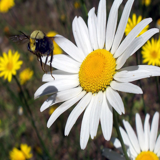

daisy 98.16199541091919


In [5]:
from PIL import Image
import random, glob, numpy as np
sample = random.choice(glob.glob(str(data_dir / "*/*.jpg")))
img = Image.open(sample).resize((IMG, IMG))
display(img)
arr = np.expand_dims(np.array(img), 0)
pred = model.predict(arr, verbose=0)[0]
print(class_names[int(np.argmax(pred))], float(np.max(pred))*100)
